#Fake news Detection

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset

In [ ]:
fake = pd.read_csv("/content/Fake.csv", engine='python', escapechar='\\', doublequote=True, on_bad_lines='skip')
real = pd.read_csv("/content/True.csv", engine='python', escapechar='\\', doublequote=True, on_bad_lines='skip')


In [ ]:
print(fake.shape)
print(real.shape)

fake.head()

(5409, 4)
(3703, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
fake["label"] = 1
real["label"] = 0

data = pd.concat([fake,real], axis=0)
data = data.sample(frac=1).reset_index(drop=True)

data.head()

,title,text,subject,date,label
0,Buy American? Even Trump’s MAGA Gear Is Sold ...,When Donald Trump kicked off Made in America ...,News,"July 24, 2017",1
1,Rachel Maddow Perfectly Explains Why Trump’s ...,We recently reported on how it has now come to...,News,"March 7, 2017",1
2,Conservative Calls President Obama A ‘Muslim’...,When former Tea Party congressman Joe Walsh de...,News,"December 30, 2016",1
3,Teen Vogue Just Just SCHOOLED Major News Netw...,"Throughout the course of the election, the mai...",News,"December 10, 2016",1
4,Trump Doubles Down On Being An Ass To Austral...,Trump isn t smart. He s a complete buffoon wit...,News,"February 2, 2017",1


#data preprocessing

In [ ]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text
data["text"] = data["text"].apply(clean_text)

# Train Test Split

In [ ]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)


#TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


# Train Model (Logistic Regression)


In [ ]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

#Model Evaluation


In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9863915715539947

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       925
           1       0.99      0.99      0.99      1353

    accuracy                           0.99      2278
   macro avg       0.99      0.99      0.99      2278
weighted avg       0.99      0.99      0.99      2278



# Confusion Matrix

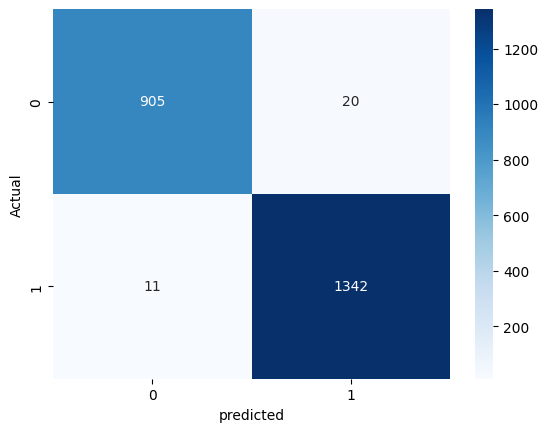

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.show()

#Prediction Function (User Input)


In [ ]:
def predict_news(text):
  cleaned = clean_text(text)
  vectorized_text = vectorizer.transform([cleaned])
  prediction = model.predict(vectorized_text)[0]

  if prediction == 1:
    return "Fake News"
  else:
    return "Real News"



In [ ]:
    print(predict_news("The government announced a new education policy today."))

Real News
